# EDA (Exploratory Data Analysis)

This Jupiter notebook will be used to perform an exploratory data analysis(EDA) on the dataset: ExoAtmospheres Database , with source at: https://research.iac.es/proyecto/exoatmospheres/index.php. 
For this compilation of data we acknowledge the use of the ExoAtmospheres database during the preparation of this work.
The aim of this EDA is to understand and visualize more in detail the data hidden in this dataset, giving a more thorough understanding of the relationship between the atmospheres and planetary paremeters the characterized exoplanets.

<img src="Table.png">



Classification for different types of exoplanets followed in this dataset

# 1. IMPORTS AND LOADING DATASET

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ExoAtmos = pd.read_csv("./Data/iac_exoplanet_atmospheres-20260311.csv",sep=";")
print("Raw shape of the dataset:", ExoAtmos.shape)

Raw shape of the dataset: (1107, 26)


Knowing the shape of our dataset, we will know take a first look into it, inspecting its first rows and enumerating its columns

In [2]:
ExoAtmos.head(2)
print("Columns in the dataset:", ExoAtmos.columns.tolist())
for i,col in enumerate(ExoAtmos.columns):
    print(f"{i}: {col}")


Columns in the dataset: ['name', 'planet_status', 'mass', 'radius', 'type', 'orbital_period', 'semi_major_axis', 'star_name', 'star_distance', 'star_teff', 'star_radius', 'temp_calculated', 'mag_v', 'mag_j', 'mag_k', 'scale_factor', 'tsm', 'esm', 'alternate_names', 'updated', 'observation_type', 'reference', 'molecules', 'albedo', 'phase_curve', 'comments']
0: name
1: planet_status
2: mass
3: radius
4: type
5: orbital_period
6: semi_major_axis
7: star_name
8: star_distance
9: star_teff
10: star_radius
11: temp_calculated
12: mag_v
13: mag_j
14: mag_k
15: scale_factor
16: tsm
17: esm
18: alternate_names
19: updated
20: observation_type
21: reference
22: molecules
23: albedo
24: phase_curve
25: comments


# 1.1. Dataset Structure & Selection Strategy

Observing the columns, this dataset splits into two clear categories:

Planet parameters: mass, radius, type, orbital_period, temp_calculated, molecules

Host star parameters: star_name, star_distance, star_teff, star_radius, mag_v/j/k

For this analysis, I'll focus on planet properties to study mass-temperature-molecule relations. Star data will get preserved separately for potential later use.

In [3]:
plnt_related_cols = []
ExoAtmos_planets = ExoAtmos[[
    'name', 'planet_status', 'mass', 'radius', 'type', 'orbital_period',
    'temp_calculated', 'observation_type', 'molecules', 'phase_curve'
]].copy()
print("Shape of the planets dataset:", ExoAtmos_planets.shape)

ExoAtmos_stars = ExoAtmos[[
    'name', 'star_name', 'star_distance', 'star_teff', 'star_radius', 
    'mag_v', 'mag_j', 'mag_k'
]].copy()
print("ExoAtmos_stars shape:", ExoAtmos_stars.shape)

Shape of the planets dataset: (1107, 10)
ExoAtmos_stars shape: (1107, 8)


# 1.2. Data refinement: Duplicate and NaN removal

Now that we have separated our dataset in two, focusing on the one at hand I will proceed with the removal of duplicated and NaN, which could be source of errors or missinformation in later analysis.

In [4]:

print("Duplicates in planets dataset:", ExoAtmos_planets.duplicated().sum())
print("\nNaNs per column:")
print(ExoAtmos_planets.isna().sum())


Duplicates in planets dataset: 142

NaNs per column:
name                 0
planet_status        0
mass                 0
radius               0
type                 0
orbital_period      12
temp_calculated     25
observation_type     0
molecules            0
phase_curve          0
dtype: int64


Proceed with the removal of the duplicates and NaNs:

In [5]:
ExoAtmos_planets_noduplicates = ExoAtmos_planets.drop_duplicates()
print("Shape after dropping duplicates:", ExoAtmos_planets_noduplicates.shape)

Shape after dropping duplicates: (965, 10)


In [6]:
ExoAtmos_planets_refined = ExoAtmos_planets_noduplicates.dropna()
print("Shape after dropping NaNs in key columns:", ExoAtmos_planets_refined.shape)
ExoAtmos_planets_refined.head(2)

Shape after dropping NaNs in key columns: (931, 10)


,name,planet_status,mass,radius,type,orbital_period,temp_calculated,observation_type,molecules,phase_curve
2,51 Eri b,Confirmed,4.1,1.11,Warm Jupiter,10260.0,700.0,G-B: High resolution IR,"{Molecular ratios: C/O, etc..."":""Detection""}""",No
3,51 Eri b,Confirmed,4.1,1.11,Warm Jupiter,10260.0,700.0,JWST-NIRCam,"{CO2"":""Detection""}""",No


 # 1.3. Provide summary statistics for our data


Now that we have our clean data it is time to inspect what it represents, for that we will use the describe method for numerical variables.

In [7]:
ExoAtmos_planets_refined.describe()

,mass,radius,orbital_period,temp_calculated
count,931.000000,931.000000,931.000000,931.000000
mean,1.509386,1.121141,273.696310,1504.672778
std,3.341921,0.944286,2555.527457,804.681167
min,0.000000,0.000000,0.070000,163.000000
25%,0.087237,0.444450,1.580404,857.453799
50%,0.690000,1.200000,2.875892,1440.978629
75%,1.490000,1.580000,4.234502,2077.000000
max,56.000000,23.043887,45108.000000,3921.000000


The .describe() output above reveals various right-skewed distributions:
* mass averages 1.51 M_Jup (median 0.69), 
* temperatures 1505 K (mostly hot atmospheres), 
* orbital periods heavily skewed (mean 274 days vs median 2.9 days),
* while temperatures range reasonably 163-3921 K

# 2. PLOTS

After "cleaning" the dataset thoroughly, we are now going to visualize the data with the objective of showing relationships between variables or data hidden in the numbers that are always easier to understand with an image

Distribution plots for relevant variables

Text(0.5, 1.0, 'Temperature Distribution')

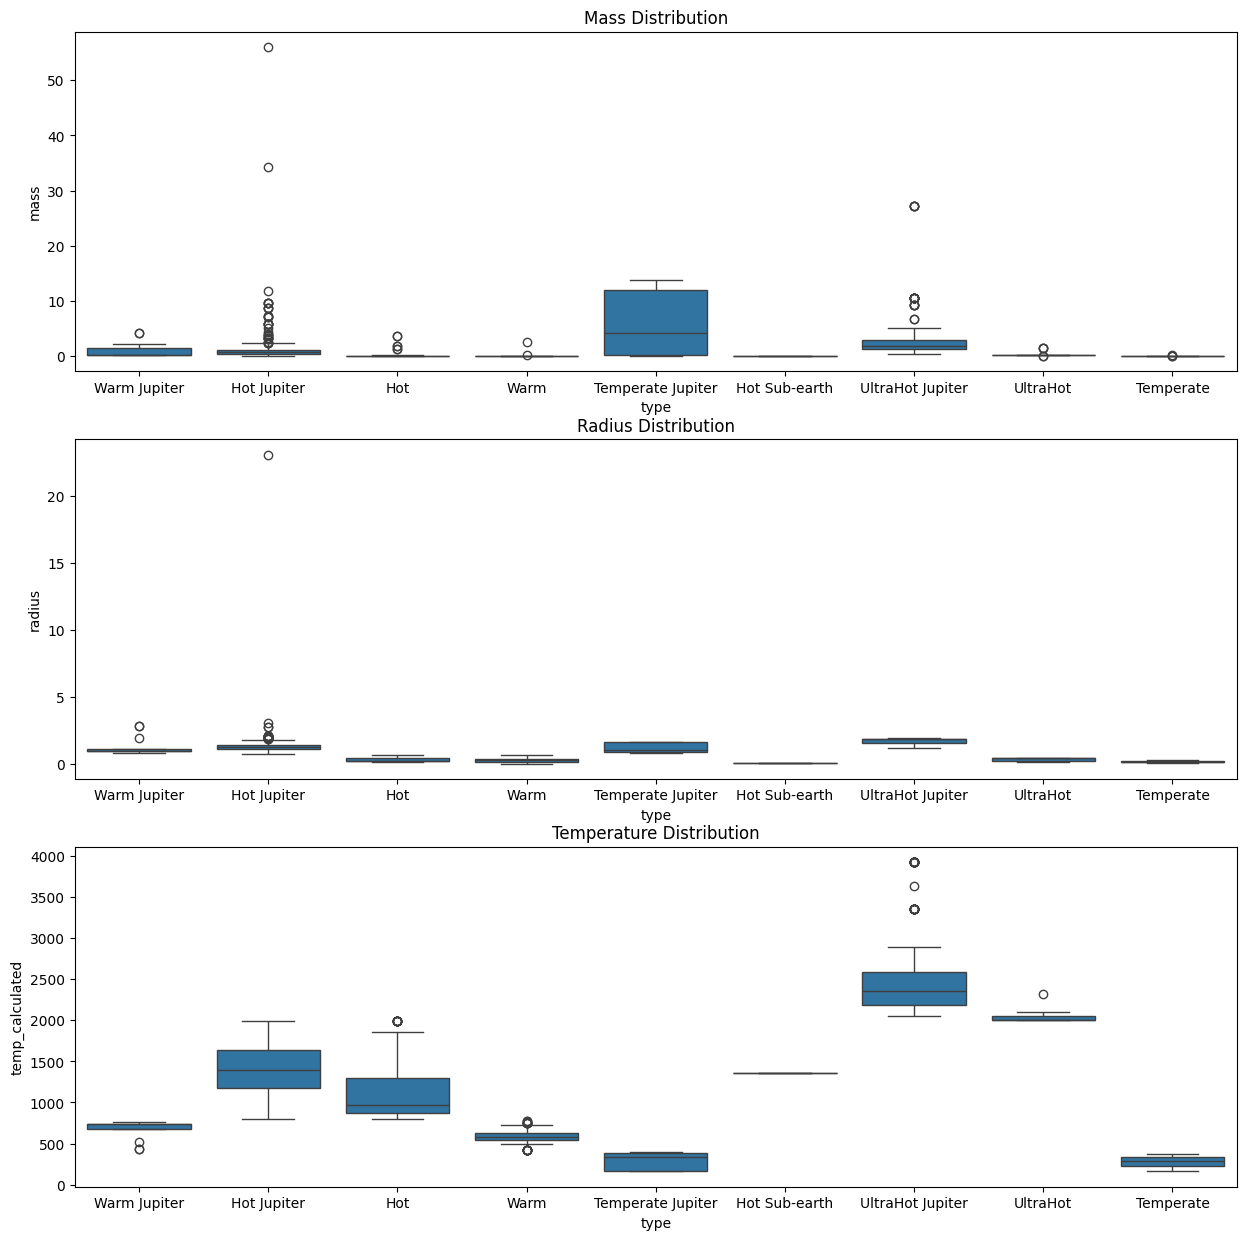

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
sns.boxplot(data=ExoAtmos_planets_refined, y='mass', x='type',  ax=axes[0])
sns.boxplot(data=ExoAtmos_planets_refined, y='radius', x='type', ax=axes[1])
sns.boxplot(data=ExoAtmos_planets_refined, y='temp_calculated', x='type', ax=axes[2])
axes[0].set_title('Mass Distribution')
axes[1].set_title('Radius Distribution')
axes[2].set_title('Temperature Distribution')

Seeing the graph above we can see that even when we refined the data, there are quite a bunch of outliers present that show mess up our graphs, and make us not see the real data, to fix that we are going to remove the outliers manually, for our relevant variables.

In [51]:
exoatmos_clean = ExoAtmos_planets_refined.copy()

Qm1 = exoatmos_clean['mass'].quantile(0.25)
Qm3 = exoatmos_clean['mass'].quantile(0.75)
IQR = Qm3 - Qm1
lower_bound = Qm1 - 0.5 * IQR  
upper_bound = Qm3 + 0.5 * IQR  

Qr1 = exoatmos_clean['radius'].quantile(0.25)
Qr3 = exoatmos_clean['radius'].quantile(0.75)
IQR_radius = Qr3 - Qr1
lower_bound_radius = Qr1 - 0.5 * IQR_radius
upper_bound_radius = Qr3 + 0.5 * IQR_radius 

Qo1 = exoatmos_clean['orbital_period'].quantile(0.25)
Qo3 = exoatmos_clean['orbital_period'].quantile(0.75)
IQR_orbital = Qo3 - Qo1
lower_bound_orbital = Qo1 - 0.5 * IQR_orbital
upper_bound_orbital = Qo3 + 0.5 * IQR_orbital

exoatmos_no_outliers = exoatmos_clean[(exoatmos_clean['mass'] >= lower_bound) & (exoatmos_clean['mass'] <= upper_bound) & (exoatmos_clean['radius'] >= lower_bound_radius) & (exoatmos_clean['radius'] <= upper_bound_radius) & (exoatmos_clean['orbital_period'] >= lower_bound_orbital) & (exoatmos_clean['orbital_period'] <= upper_bound_orbital)]

Text(0.5, 1.0, 'Temperature Distribution')

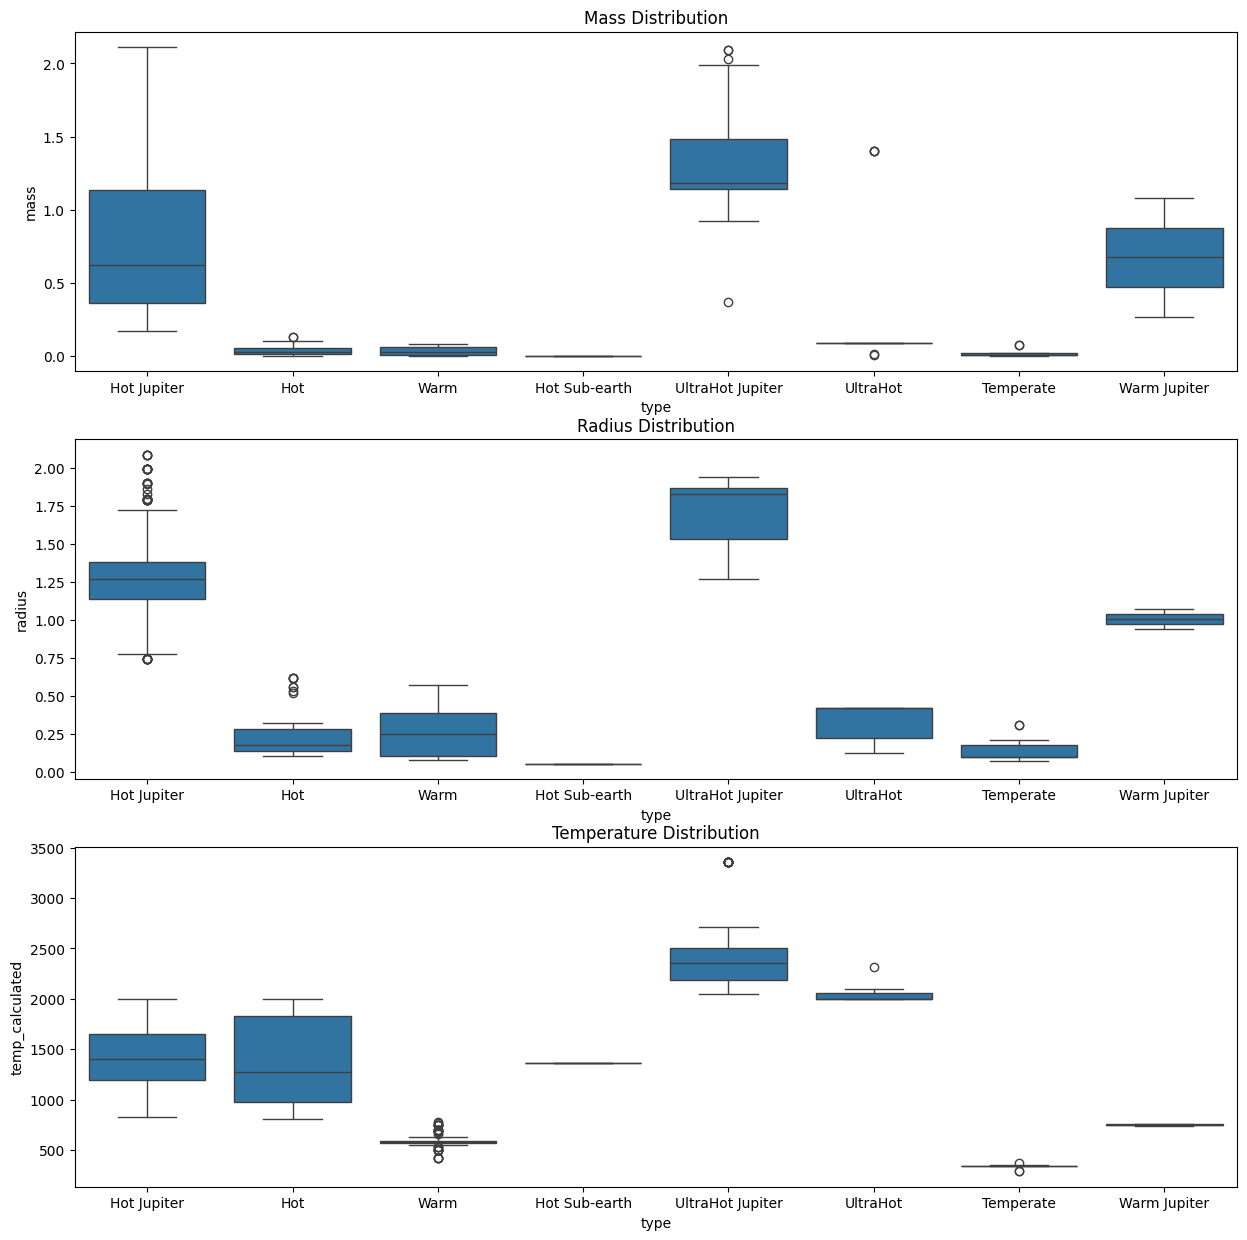

In [52]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
sns.boxplot(data=exoatmos_no_outliers, y='mass', x='type',  ax=axes[0])
sns.boxplot(data=exoatmos_no_outliers, y='radius', x='type', ax=axes[1])
sns.boxplot(data=exoatmos_no_outliers, y='temp_calculated', x='type', ax=axes[2])
axes[0].set_title('Mass Distribution')
axes[1].set_title('Radius Distribution')
axes[2].set_title('Temperature Distribution')

We can now observe the data that is more representative of the our dataset

<Axes: xlabel='orbital_period', ylabel='Count'>

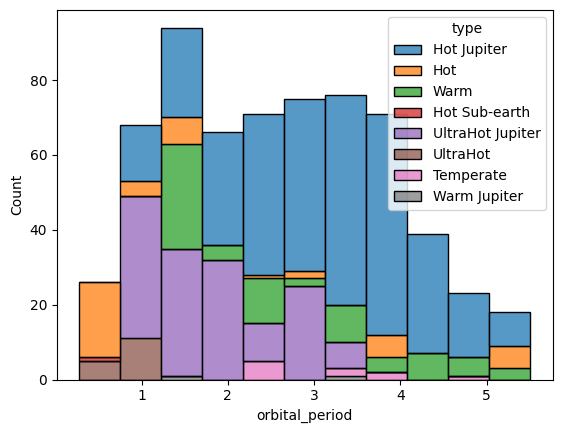

In [54]:
sns.histplot(data=exoatmos_no_outliers, x="orbital_period", hue="type", multiple="stack")


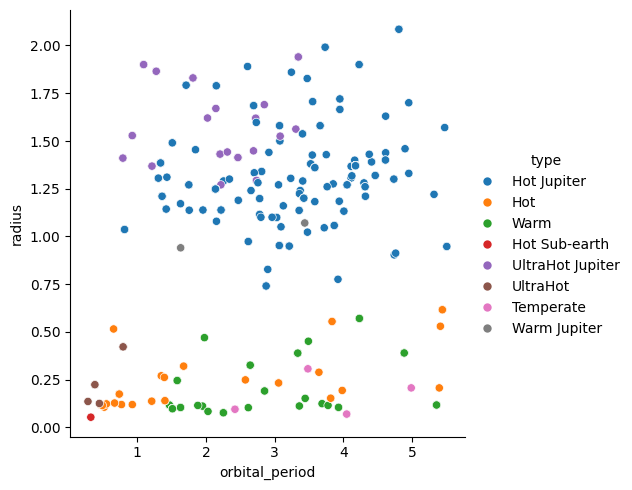

In [55]:

sns.relplot(data=exoatmos_no_outliers, x='orbital_period', y='radius', hue='type')


Calculate and correlation between key variables

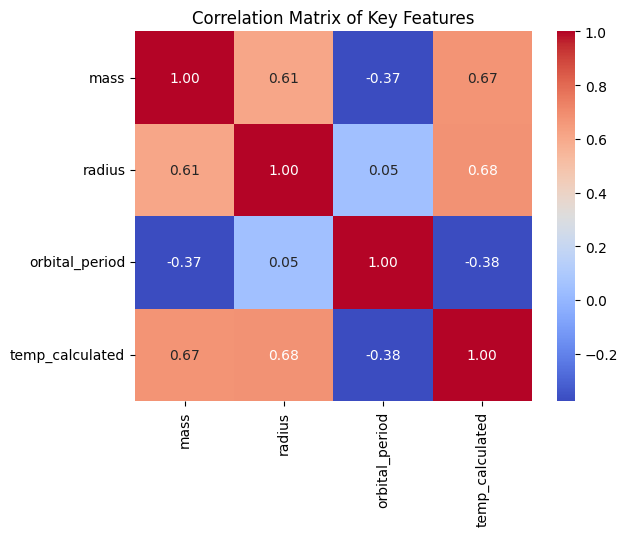

In [56]:
correlation_matrix = exoatmos_no_outliers[['mass', 'radius', 'orbital_period', 'temp_calculated']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()